<a href="https://colab.research.google.com/github/IshaanMhalgi1/mlassignments/blob/main/ass5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Assignment 5

Importing data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('/content/uber.csv')
del df['Unnamed: 0']
df

,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5
...,...,...,...,...,...,...,...,...
199995,2012-10-28 10:49:00.00000053,3.0,2012-10-28 10:49:00 UTC,-73.987042,40.739367,-73.986525,40.740297,1
199996,2014-03-14 01:09:00.0000008,7.5,2014-03-14 01:09:00 UTC,-73.984722,40.736837,-74.006672,40.739620,1
199997,2009-06-29 00:42:00.00000078,30.9,2009-06-29 00:42:00 UTC,-73.986017,40.756487,-73.858957,40.692588,2
199998,2015-05-20 14:56:25.0000004,14.5,2015-05-20 14:56:25 UTC,-73.997124,40.725452,-73.983215,40.695415,1


Data cleaning and scaling

In [ ]:
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

In [ ]:
df = df[(df['fare_amount'] > 0) & (df['fare_amount'] < 200)]
df = df[(df['passenger_count'] >= 1) & (df['passenger_count'] <= 6)]
df = df[
    (df['pickup_latitude'].between(-90, 90)) &
    (df['dropoff_latitude'].between(-90, 90)) &
    (df['pickup_longitude'].between(-180, 180)) &
    (df['dropoff_longitude'].between(-180, 180))
]

Distance calculation using haversine formula

In [ ]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

df['distance_km'] = haversine(
    df['pickup_latitude'],
    df['pickup_longitude'],
    df['dropoff_latitude'],
    df['dropoff_longitude']
)

In [ ]:
df = df[(df['distance_km'] > 0) & (df['distance_km'] < 50)]

BoxPlot to find outliers

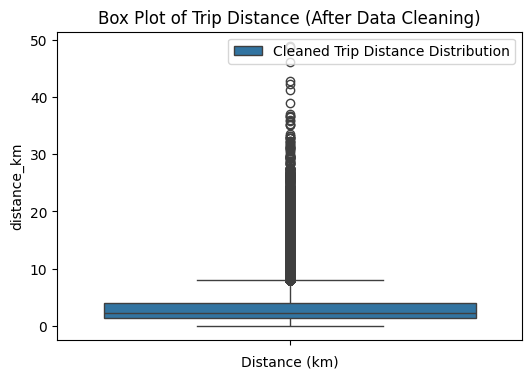

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(df['distance_km'])
plt.title("Box Plot of Trip Distance (After Data Cleaning)")
plt.xlabel("Distance (km)")
plt.legend(["Cleaned Trip Distance Distribution"])


plt.show()

Heatmap

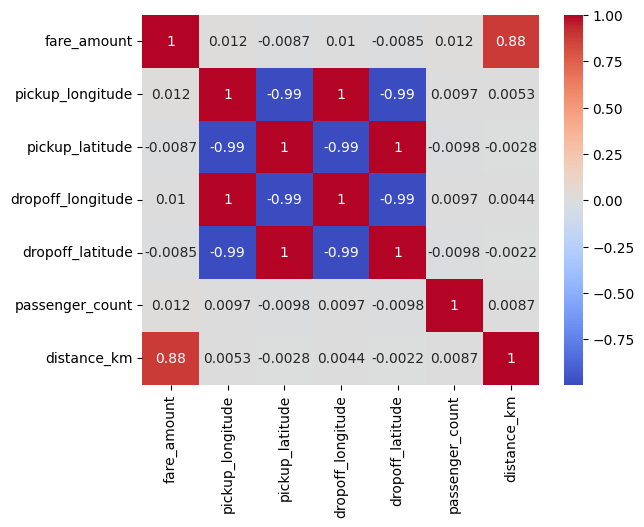

In [ ]:
import seaborn as sns
numeric_df = df[['fare_amount','pickup_longitude','pickup_latitude','dropoff_longitude','dropoff_latitude','passenger_count','distance_km']]
corr_matrix = numeric_df.corr()
sns.heatmap(corr_matrix,annot=True, cmap='coolwarm')

plt.show()

Correlation analysis

In [ ]:
numeric_df.corr()

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance_km
fare_amount,1.000000,0.011859,-0.008661,0.010401,-0.008487,0.012428,0.876068
pickup_longitude,0.011859,1.000000,-0.994005,0.999884,-0.993973,0.009670,0.005343
pickup_latitude,-0.008661,-0.994005,1.000000,-0.993993,0.999929,-0.009828,-0.002833
dropoff_longitude,0.010401,0.999884,-0.993993,1.000000,-0.993960,0.009665,0.004436
dropoff_latitude,-0.008487,-0.993973,0.999929,-0.993960,1.000000,-0.009785,-0.002162
passenger_count,0.012428,0.009670,-0.009828,0.009665,-0.009785,1.000000,0.008684
distance_km,0.876068,0.005343,-0.002833,0.004436,-0.002162,0.008684,1.000000


Pearson Correlation

In [ ]:
numeric_df.corr(method='pearson')

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance_km
fare_amount,1.000000,0.011859,-0.008661,0.010401,-0.008487,0.012428,0.876068
pickup_longitude,0.011859,1.000000,-0.994005,0.999884,-0.993973,0.009670,0.005343
pickup_latitude,-0.008661,-0.994005,1.000000,-0.993993,0.999929,-0.009828,-0.002833
dropoff_longitude,0.010401,0.999884,-0.993993,1.000000,-0.993960,0.009665,0.004436
dropoff_latitude,-0.008487,-0.993973,0.999929,-0.993960,1.000000,-0.009785,-0.002162
passenger_count,0.012428,0.009670,-0.009828,0.009665,-0.009785,1.000000,0.008684
distance_km,0.876068,0.005343,-0.002833,0.004436,-0.002162,0.008684,1.000000


Spearman Correlation

In [ ]:
numeric_df.corr(method='spearman')

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance_km
fare_amount,1.000000,0.046014,-0.076605,0.108856,-0.090612,0.023002,0.858213
pickup_longitude,0.046014,1.000000,0.607193,0.362431,0.284187,-0.016450,0.054536
pickup_latitude,-0.076605,0.607193,1.000000,0.264280,0.465036,-0.017464,-0.060813
dropoff_longitude,0.108856,0.362431,0.264280,1.000000,0.555749,-0.012912,0.137961
dropoff_latitude,-0.090612,0.284187,0.465036,0.555749,1.000000,-0.010018,-0.053266
passenger_count,0.023002,-0.016450,-0.017464,-0.012912,-0.010018,1.000000,0.014772
distance_km,0.858213,0.054536,-0.060813,0.137961,-0.053266,0.014772,1.000000


Kendall Correlation

In [ ]:
numeric_df.corr(method='kendall')

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance_km
fare_amount,1.000000,0.029792,-0.053178,0.073430,-0.062751,0.018007,0.701091
pickup_longitude,0.029792,1.000000,0.454238,0.251111,0.194907,-0.012780,0.036323
pickup_latitude,-0.053178,0.454238,1.000000,0.181613,0.329335,-0.013557,-0.042038
dropoff_longitude,0.073430,0.251111,0.181613,1.000000,0.420937,-0.010003,0.093498
dropoff_latitude,-0.062751,0.194907,0.329335,0.420937,1.000000,-0.007772,-0.037094
passenger_count,0.018007,-0.012780,-0.013557,-0.010003,-0.007772,1.000000,0.011464
distance_km,0.701091,0.036323,-0.042038,0.093498,-0.037094,0.011464,1.000000


Model training

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error

In [ ]:
data = pd.read_csv('/content/sample_data/california_housing_test.csv')
data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.05,37.37,27.0,3885.0,661.0,1537.0,606.0,6.6085,344700.0
1,-118.30,34.26,43.0,1510.0,310.0,809.0,277.0,3.5990,176500.0
2,-117.81,33.78,27.0,3589.0,507.0,1484.0,495.0,5.7934,270500.0
3,-118.36,33.82,28.0,67.0,15.0,49.0,11.0,6.1359,330000.0
4,-119.67,36.33,19.0,1241.0,244.0,850.0,237.0,2.9375,81700.0
...,...,...,...,...,...,...,...,...,...
2995,-119.86,34.42,23.0,1450.0,642.0,1258.0,607.0,1.1790,225000.0
2996,-118.14,34.06,27.0,5257.0,1082.0,3496.0,1036.0,3.3906,237200.0
2997,-119.70,36.30,10.0,956.0,201.0,693.0,220.0,2.2895,62000.0
2998,-117.12,34.10,40.0,96.0,14.0,46.0,14.0,3.2708,162500.0


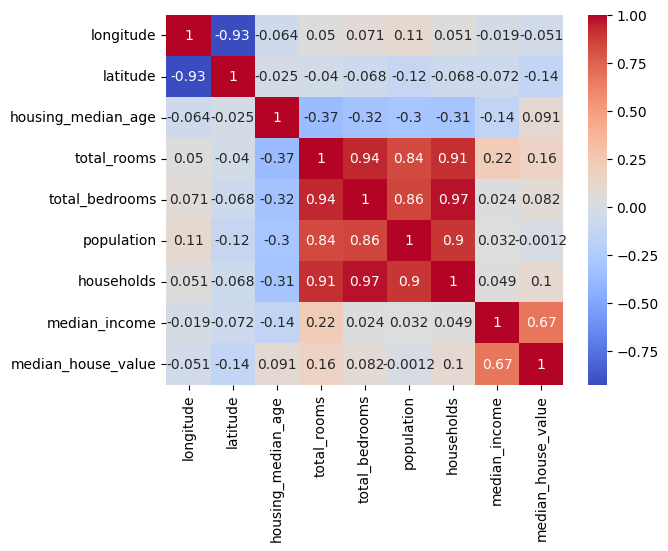

In [ ]:
data.dropna()
corre_matrix = data.corr()
sns.heatmap(corre_matrix,annot=True, cmap='coolwarm')

plt.show()

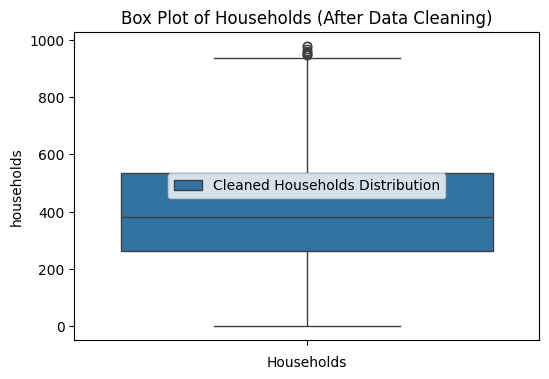

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(data['households'])
plt.title("Box Plot of Households (After Data Cleaning)")
plt.xlabel("Households")
plt.legend(["Cleaned Households Distribution"])


plt.show()

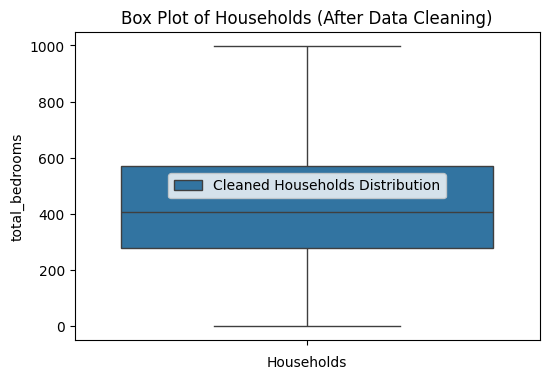

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(data['total_bedrooms'])
plt.title("Box Plot of Households (After Data Cleaning)")
plt.xlabel("Households")
plt.legend(["Cleaned Households Distribution"])


plt.show()

In [ ]:
data = data[data['households']<1000]
data = data[data['total_bedrooms']<1000]
data.drop_duplicates()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,Predicted_households
0,-122.05,37.37,27.0,3885.0,661.0,1537.0,606.0,6.6085,344700.0,639.382989
1,-118.30,34.26,43.0,1510.0,310.0,809.0,277.0,3.5990,176500.0,298.020227
2,-117.81,33.78,27.0,3589.0,507.0,1484.0,495.0,5.7934,270500.0,524.211966
3,-118.36,33.82,28.0,67.0,15.0,49.0,11.0,6.1359,330000.0,22.024802
4,-119.67,36.33,19.0,1241.0,244.0,850.0,237.0,2.9375,81700.0,256.517155
...,...,...,...,...,...,...,...,...,...,...
2994,-117.93,33.86,35.0,931.0,181.0,516.0,174.0,5.5867,182500.0,191.149818
2995,-119.86,34.42,23.0,1450.0,642.0,1258.0,607.0,1.1790,225000.0,640.420566
2997,-119.70,36.30,10.0,956.0,201.0,693.0,220.0,2.2895,62000.0,238.878350
2998,-117.12,34.10,40.0,96.0,14.0,46.0,14.0,3.2708,162500.0,25.137532


In [ ]:
X = data[['households']]
y = data['total_bedrooms']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Linear Regression, Ridge and Lasso models

In [ ]:
lr = LinearRegression()
ridge = Ridge(alpha=1.0)
lasso = Lasso(alpha=0.01)

lr.fit(X_train, y_train)
ridge.fit(X_train, y_train)
lasso.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_pred_ridge = ridge.predict(X_test)
y_pred_lasso = lasso.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


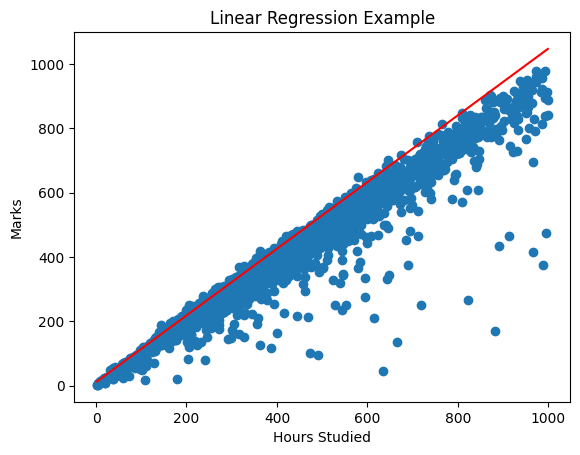

In [ ]:
X_line = np.linspace(
    data['total_bedrooms'].min(),
    data['total_bedrooms'].max(),
    2719
).reshape(-1, 1)
plt.scatter(data['total_bedrooms'], data['households'])
y_line = lr.predict(X_line)
plt.plot(X_line, y_line, color='red')
plt.xlabel("Tot")
plt.ylabel("Marks")
plt.title("Linear Regression Example")
plt.show()

Model Evaluation

In [ ]:
def evaluate_model(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return r2, rmse

results = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression", "Lasso Regression"],
    "R2 Score": [
        evaluate_model(y_test, y_pred_lr)[0],
        evaluate_model(y_test, y_pred_ridge)[0],
        evaluate_model(y_test, y_pred_lasso)[0]
    ],
    "RMSE": [
        evaluate_model(y_test, y_pred_lr)[1],
        evaluate_model(y_test, y_pred_ridge)[1],
        evaluate_model(y_test, y_pred_lasso)[1]
    ]
})

results

,Model,R2 Score,RMSE
0,Linear Regression,0.919563,62.170209
1,Ridge Regression,0.919563,62.170209
2,Lasso Regression,0.919563,62.170206


#Conclusion:
All models have the same R2 score and RMSE value meaning distance is already a good predictor of the uber fare